# Beauty Ecommerce — Retention Cohort Analysis

**Objective:** Build a cohort model showing how D7 / D30 / D90 retention decays by acquisition channel and first-order category across 6 signup cohort months.

**Dataset:** Synthetic — mirrors Olist schema field-for-field. 5,000 users, Sep 2024 – Feb 2025.  
Retention coefficients are explicitly documented in Step 3 so every assumption is visible and challengeable.

**Tables generated:**
| Table | Key fields |
|---|---|
| `customers` | customer_unique_id, customer_id, acq_channel, first_category |
| `orders` | order_id, customer_id, customer_unique_id, order_purchase_timestamp, activity_window |
| `order_items` | order_id, product_id, price |
| `products` | product_id, product_category_name |

**Note on `customer_unique_id` vs `customer_id`:**  
Mirrors the real Olist schema. `customer_unique_id` is the stable repeat-customer key. `customer_id` is issued fresh per order — querying retention on `customer_id` alone would show 0% repeat rate and is a common modelling mistake.

## Step 1 — Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import uuid
import hashlib
import warnings
from datetime import datetime, timedelta
from pandasql import sqldf

warnings.filterwarnings('ignore')

# ── Global constants ────────────────────────────────────────────────
SEED       = 42
N_USERS    = 5000
START_DATE = datetime(2024, 9, 1)
END_DATE   = datetime(2025, 2, 28)

CATEGORIES = [
    'Health & Beauty',  # high replenishment cadence
    'Fragrance',        # high AOV, low reorder frequency
    'Personal Care',    # medium replenishment
    'Haircare',         # medium replenishment
    'Makeup',           # trend-driven, low repeat intent
]
CATEGORY_WEIGHTS = [0.35, 0.10, 0.20, 0.20, 0.15]

CHANNELS        = ['Google Search', 'Instagram / Meta Paid', 'Influencer & Creator', 'App Organic', 'Referral Program']
CHANNEL_WEIGHTS = [0.35, 0.25, 0.20, 0.12, 0.08]

PRICE_RANGES = {
    'Health & Beauty': (299,  1499),
    'Fragrance':        (799,  4999),
    'Personal Care':    (199,   999),
    'Haircare':         (249,  1299),
    'Makeup':           (199,  1999),
}

rng = np.random.default_rng(SEED)

print(f'Environment ready. Seed: {SEED}')
print(f'Simulating {N_USERS:,} users | {START_DATE:%b %Y} - {END_DATE:%b %Y}')

Environment ready. Seed: 42
Simulating 5,000 users | Sep 2024 - Feb 2025


## Step 2 — Simulate Base Tables

In [2]:
# ── Deterministic UUID helpers ───────────────────────────────────────
# hashlib.md5 avoids numpy int64 overflow (2**128 > int64 max).
# Same seed always produces identical IDs.
def make_uuid(prefix, idx):
    return str(uuid.UUID(hashlib.md5(f'{prefix}{idx}'.encode()).hexdigest()))

# ── customers table ──────────────────────────────────────────────────
customer_unique_ids = [make_uuid('u', i) for i in range(N_USERS)]
first_customer_ids  = [make_uuid('c', i) for i in range(N_USERS)]

acq_channels     = rng.choice(CHANNELS,   size=N_USERS, p=CHANNEL_WEIGHTS)
first_categories = rng.choice(CATEGORIES, size=N_USERS, p=CATEGORY_WEIGHTS)

total_days        = (END_DATE - START_DATE).days
offsets           = rng.integers(0, total_days, size=N_USERS)
first_order_dates = [START_DATE + timedelta(days=int(d)) for d in offsets]

customers = pd.DataFrame({
    'customer_unique_id': customer_unique_ids,
    'customer_id':        first_customer_ids,
    'acq_channel':        acq_channels,
    'first_category':     first_categories,
    'first_order_date':   first_order_dates,
})

print('customers table:', customers.shape)
customers.head(5)

customers table: (5000, 5)


,customer_unique_id,customer_id,acq_channel,first_category,first_order_date
0,3e334e85-9879-af25-6d38-27d651b7804a,b0fce403-c178-fa57-404c-1cc4176547a8,Influencer & Creator,Health & Beauty,2024-09-07
1,e4774cdd-a079-3f86-414e-8b9140bb6db4,a9f7e979-65d6-cf79-9a52-9102a973b8b9,Instagram / Meta Paid,Haircare,2025-01-08
2,270c1b08-4f3f-146e-b578-7075158d9c53,9ab62b5e-f34a-9854-38bf-df7ee0102229,App Organic,Haircare,2024-10-09
3,532a7b8e-0328-a8d0-5a8e-6258b28b9a36,0a3d7213-4fb3-d6c0-24db-4c510bc1605b,Influencer & Creator,Health & Beauty,2025-01-07
4,7b8d62fd-2f0f-5b2e-3ba5-437e5b983128,cb7524d7-9232-7e4c-443d-619de5c71a7a,Google Search,Health & Beauty,2024-12-11


## Step 3 — Retention Coefficient Matrix

Every assumption is explicit. Each cell = **probability** a user in that `channel x category` bucket places at least one order in that activity window.

**Two hypotheses baked in:**
1. **Instagram / Meta Paid x Makeup** — D7: 0.07, D30: 0.09. Trend purchase, no return intent. Sharp cliff.
2. **Google Search x Health & Beauty** — D7: 0.22, D30: 0.41. D30 > D7 inversion = replenishment cycle. User ran out of product and came back.

These are the two segments the insight doc will interrogate.

In [3]:
# (p_d7, p_d30, p_d90) per channel x category
coefficients = {
    'Google Search': {
        'Health & Beauty': (0.22, 0.41, 0.35),  # D30 > D7 replenishment inversion
        'Fragrance':       (0.08, 0.14, 0.18),
        'Personal Care':   (0.18, 0.30, 0.28),
        'Haircare':        (0.16, 0.28, 0.26),
        'Makeup':          (0.14, 0.20, 0.17),
    },
    'Instagram / Meta Paid': {
        'Health & Beauty': (0.14, 0.18, 0.14),
        'Fragrance':       (0.10, 0.13, 0.11),
        'Personal Care':   (0.12, 0.16, 0.13),
        'Haircare':        (0.11, 0.15, 0.12),
        'Makeup':          (0.07, 0.09, 0.08),  # D7 cliff — trend purchase
    },
    'Influencer & Creator': {
        'Health & Beauty': (0.18, 0.28, 0.24),
        'Fragrance':       (0.12, 0.18, 0.15),
        'Personal Care':   (0.15, 0.22, 0.19),
        'Haircare':        (0.14, 0.21, 0.18),
        'Makeup':          (0.16, 0.22, 0.18),
    },
    'Referral Program': {
        'Health & Beauty': (0.28, 0.44, 0.40),  # highest retention — high-intent acquisition
        'Fragrance':       (0.14, 0.22, 0.20),
        'Personal Care':   (0.22, 0.35, 0.31),
        'Haircare':        (0.20, 0.33, 0.29),
        'Makeup':          (0.18, 0.26, 0.22),
    },
    'App Organic': {
        'Health & Beauty': (0.20, 0.34, 0.30),
        'Fragrance':       (0.10, 0.16, 0.14),
        'Personal Care':   (0.16, 0.26, 0.23),
        'Haircare':        (0.15, 0.25, 0.22),
        'Makeup':          (0.13, 0.19, 0.16),
    },
}

# Display as pivot — D30 values
rows = []
for ch in CHANNELS:
    for cat in CATEGORIES:
        p = coefficients[ch].get(cat, (0.15, 0.25, 0.20))
        rows.append({'channel': ch, 'category': cat,
                     'p_d7': p[0], 'p_d30': p[1], 'p_d90': p[2]})
coeff_df = pd.DataFrame(rows)

print('D30 retention probability matrix (input assumptions):')
coeff_df.pivot(index='channel', columns='category', values='p_d30').round(2)

D30 retention probability matrix (input assumptions):


category,Fragrance,Haircare,Health & Beauty,Makeup,Personal Care
channel,,,,,
App Organic,0.16,0.25,0.34,0.19,0.26
Google Search,0.14,0.28,0.41,0.20,0.30
Influencer & Creator,0.18,0.21,0.28,0.22,0.22
Instagram / Meta Paid,0.13,0.15,0.18,0.09,0.16
Referral Program,0.22,0.33,0.44,0.26,0.35


## Step 4 — Generate Order History

In [4]:
def rand_ts(base_date, day_start, day_end):
    """Random timestamp within [base_date + day_start, base_date + day_end]."""
    offset = int(rng.integers(day_start, day_end + 1))
    hour   = int(rng.integers(6, 23))
    minute = int(rng.integers(0, 60))
    return base_date + timedelta(days=offset, hours=hour, minutes=minute)

_ctr = [0]
def _next(prefix):
    _ctr[0] += 1
    return make_uuid(prefix, _ctr[0])

all_orders, all_items, all_products = [], [], []

WINDOWS = [
    ('D2_7',   2,  7,  'p_d7'),
    ('D8_30',  8,  30, 'p_d30'),
    ('D31_90', 31, 90, 'p_d90'),
]

for _, user in customers.iterrows():
    ch   = user['acq_channel']
    cat  = user['first_category']
    base = user['first_order_date']
    uid  = user['customer_unique_id']
    p_d7, p_d30, p_d90 = coefficients[ch].get(cat, (0.15, 0.25, 0.20))

    # D0: first order — always generated
    oid = _next('o'); pid = _next('p')
    all_orders.append({
        'order_id': oid, 'customer_id': user['customer_id'],
        'customer_unique_id': uid, 'order_purchase_timestamp': base,
        'order_status': 'delivered', 'activity_window': 'D0_1',
    })
    all_items.append({'order_id': oid, 'product_id': pid,
                      'price': round(float(rng.uniform(*PRICE_RANGES[cat])), 2)})
    all_products.append({'product_id': pid, 'product_category_name': cat})

    # Repeat windows: Bernoulli trial per window
    for window, d0, d1, prob_key in WINDOWS:
        prob = {'p_d7': p_d7, 'p_d30': p_d30, 'p_d90': p_d90}[prob_key]
        if rng.random() < prob:
            ts  = rand_ts(base, d0, d1)
            oid = _next('o'); pid = _next('p'); cid = _next('r')
            all_orders.append({
                'order_id': oid, 'customer_id': cid,
                'customer_unique_id': uid, 'order_purchase_timestamp': ts,
                'order_status': 'delivered', 'activity_window': window,
            })
            all_items.append({'order_id': oid, 'product_id': pid,
                              'price': round(float(rng.uniform(*PRICE_RANGES[cat])), 2)})
            all_products.append({'product_id': pid, 'product_category_name': cat})

orders      = pd.DataFrame(all_orders)
order_items = pd.DataFrame(all_items).drop_duplicates('order_id')
products    = pd.DataFrame(all_products).drop_duplicates('product_id')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print(f'orders:      {orders.shape[0]:,} rows')
print(f'order_items: {order_items.shape[0]:,} rows')
print(f'products:    {products.shape[0]:,} rows')
print()
print('Orders per activity window:')
print(orders['activity_window'].value_counts().to_string())

orders:      8,141 rows
order_items: 8,141 rows
products:    8,141 rows

Orders per activity window:
activity_window
D0_1      5000
D8_30     1234
D31_90    1123
D2_7       784


## Step 5 — Head(5) of All Four Tables

In [5]:
print('customers')
display(customers.head(5))

print('orders')
display(orders.head(5))

print('order_items')
display(order_items.head(5))

print('products')
display(products.head(5))

customers


,customer_unique_id,customer_id,acq_channel,first_category,first_order_date
0,3e334e85-9879-af25-6d38-27d651b7804a,b0fce403-c178-fa57-404c-1cc4176547a8,Influencer & Creator,Health & Beauty,2024-09-07
1,e4774cdd-a079-3f86-414e-8b9140bb6db4,a9f7e979-65d6-cf79-9a52-9102a973b8b9,Instagram / Meta Paid,Haircare,2025-01-08
2,270c1b08-4f3f-146e-b578-7075158d9c53,9ab62b5e-f34a-9854-38bf-df7ee0102229,App Organic,Haircare,2024-10-09
3,532a7b8e-0328-a8d0-5a8e-6258b28b9a36,0a3d7213-4fb3-d6c0-24db-4c510bc1605b,Influencer & Creator,Health & Beauty,2025-01-07
4,7b8d62fd-2f0f-5b2e-3ba5-437e5b983128,cb7524d7-9232-7e4c-443d-619de5c71a7a,Google Search,Health & Beauty,2024-12-11


orders


,order_id,customer_id,customer_unique_id,order_purchase_timestamp,order_status,activity_window
0,f1584b99-5a47-7098-6ad7-5bb8d29e9734,b0fce403-c178-fa57-404c-1cc4176547a8,3e334e85-9879-af25-6d38-27d651b7804a,2024-09-07 00:00:00,delivered,D0_1
1,417c4fa3-b413-5a6c-64e0-5f8d35f71648,ed84d589-f231-f3dc-4203-153e6fb4b4d5,3e334e85-9879-af25-6d38-27d651b7804a,2024-09-09 10:24:00,delivered,D2_7
2,39d987fd-8304-752b-bbec-0bd1afd4b7f3,90a071d6-a73f-529d-a5ef-eb75b4cec839,3e334e85-9879-af25-6d38-27d651b7804a,2024-10-05 16:42:00,delivered,D8_30
3,ab0fd361-fde5-c362-5fe7-6007f204cc04,a9f7e979-65d6-cf79-9a52-9102a973b8b9,e4774cdd-a079-3f86-414e-8b9140bb6db4,2025-01-08 00:00:00,delivered,D0_1
4,fd8004ec-2f65-cb08-9a6c-384133d405d2,0839f88a-e61e-faa3-e91f-df5b732b242f,e4774cdd-a079-3f86-414e-8b9140bb6db4,2025-01-15 09:28:00,delivered,D2_7


order_items


,order_id,product_id,price
0,f1584b99-5a47-7098-6ad7-5bb8d29e9734,1d665b9b-1467-944c-128a-5575119d1cfd,1182.33
1,417c4fa3-b413-5a6c-64e0-5f8d35f71648,13207e3d-5722-030f-6c97-d69b4904d39d,991.30
2,39d987fd-8304-752b-bbec-0bd1afd4b7f3,46d46a75-9bf6-cbed-05d7-bcdcb911a4f8,907.02
3,ab0fd361-fde5-c362-5fe7-6007f204cc04,ad304601-e663-8bf2-bcdd-5345c013a6c1,965.56
4,fd8004ec-2f65-cb08-9a6c-384133d405d2,d3d078bf-2fc1-425e-6d44-10ccb6ed6df9,986.34


products


,product_id,product_category_name
0,1d665b9b-1467-944c-128a-5575119d1cfd,Health & Beauty
1,13207e3d-5722-030f-6c97-d69b4904d39d,Health & Beauty
2,46d46a75-9bf6-cbed-05d7-bcdcb911a4f8,Health & Beauty
3,ad304601-e663-8bf2-bcdd-5345c013a6c1,Haircare
4,d3d078bf-2fc1-425e-6d44-10ccb6ed6df9,Haircare


In [6]:
print('Channel split (customers):')
print((customers['acq_channel'].value_counts(normalize=True)*100).round(1).to_string())
print()
print('First category split (customers):')
print((customers['first_category'].value_counts(normalize=True)*100).round(1).to_string())
print()
print('Order date range:')
print(f"  Min: {orders['order_purchase_timestamp'].min()}")
print(f"  Max: {orders['order_purchase_timestamp'].max()}")
print()
print('Price stats per category:')
oi_cat = order_items.merge(products, on='product_id')
display(oi_cat.groupby('product_category_name')['price'].describe().round(0))

Channel split (customers):
acq_channel
Google Search            36.1
Instagram / Meta Paid    24.9
Influencer & Creator     19.3
App Organic              11.7
Referral Program          8.0

First category split (customers):
first_category
Health & Beauty    34.8
Haircare           20.2
Personal Care      20.0
Makeup             14.6
Fragrance          10.4

Order date range:
  Min: 2024-09-01 00:00:00
  Max: 2025-05-27 19:45:00

Price stats per category:


,count,mean,std,min,25%,50%,75%,max
product_category_name,,,,,,,,
Fragrance,735.0,2973.0,1221.0,801.0,1919.0,3053.0,4026.0,4991.0
Haircare,1613.0,767.0,300.0,249.0,499.0,763.0,1023.0,1299.0
Health & Beauty,3111.0,899.0,349.0,299.0,592.0,896.0,1204.0,1499.0
Makeup,1082.0,1117.0,518.0,200.0,668.0,1115.0,1562.0,1999.0
Personal Care,1600.0,601.0,230.0,200.0,408.0,602.0,796.0,999.0


## Step 6 — Cohort SQL Model

**CTE 1 `cohort_base`** — each user's signup_month, first_category, acq_channel  
**CTE 2 `activity_buckets`** — every order tagged with days_since_first_order  
**CTE 3 `retention_rates`** — % of cohort active per window, by signup_month x acq_channel x first_category

In [7]:
pysqldf = lambda q: sqldf(q, globals())

cohort_base = pysqldf("""
WITH first_orders AS (
    SELECT
        customer_unique_id,
        MIN(order_purchase_timestamp)                      AS first_order_ts,
        STRFTIME('%Y-%m', MIN(order_purchase_timestamp))   AS signup_month
    FROM orders
    WHERE activity_window = 'D0_1'
    GROUP BY customer_unique_id
)
SELECT
    f.customer_unique_id,
    f.first_order_ts,
    f.signup_month,
    c.acq_channel,
    c.first_category
FROM first_orders f
JOIN customers c ON f.customer_unique_id = c.customer_unique_id
""")

print('cohort_base:', cohort_base.shape)
print('Signup months:', sorted(cohort_base['signup_month'].unique()))
cohort_base.head(5)

cohort_base: (5000, 5)
Signup months: ['2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02']


,customer_unique_id,first_order_ts,signup_month,acq_channel,first_category
0,3e334e85-9879-af25-6d38-27d651b7804a,2024-09-07 00:00:00.000000,2024-09,Influencer & Creator,Health & Beauty
1,e4774cdd-a079-3f86-414e-8b9140bb6db4,2025-01-08 00:00:00.000000,2025-01,Instagram / Meta Paid,Haircare
2,270c1b08-4f3f-146e-b578-7075158d9c53,2024-10-09 00:00:00.000000,2024-10,App Organic,Haircare
3,532a7b8e-0328-a8d0-5a8e-6258b28b9a36,2025-01-07 00:00:00.000000,2025-01,Influencer & Creator,Health & Beauty
4,7b8d62fd-2f0f-5b2e-3ba5-437e5b983128,2024-12-11 00:00:00.000000,2024-12,Google Search,Health & Beauty


In [8]:
activity_buckets = pysqldf("""
SELECT
    o.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    o.activity_window,
    cb.signup_month,
    cb.acq_channel,
    cb.first_category,
    CAST(
        JULIANDAY(o.order_purchase_timestamp) - JULIANDAY(cb.first_order_ts)
    AS INTEGER) AS days_since_first
FROM orders o
JOIN cohort_base cb ON o.customer_unique_id = cb.customer_unique_id
""")

print('activity_buckets:', activity_buckets.shape)
activity_buckets.head(5)

activity_buckets: (8141, 8)


,customer_unique_id,order_id,order_purchase_timestamp,activity_window,signup_month,acq_channel,first_category,days_since_first
0,3e334e85-9879-af25-6d38-27d651b7804a,f1584b99-5a47-7098-6ad7-5bb8d29e9734,2024-09-07 00:00:00.000000,D0_1,2024-09,Influencer & Creator,Health & Beauty,0
1,3e334e85-9879-af25-6d38-27d651b7804a,417c4fa3-b413-5a6c-64e0-5f8d35f71648,2024-09-09 10:24:00.000000,D2_7,2024-09,Influencer & Creator,Health & Beauty,2
2,3e334e85-9879-af25-6d38-27d651b7804a,39d987fd-8304-752b-bbec-0bd1afd4b7f3,2024-10-05 16:42:00.000000,D8_30,2024-09,Influencer & Creator,Health & Beauty,28
3,e4774cdd-a079-3f86-414e-8b9140bb6db4,ab0fd361-fde5-c362-5fe7-6007f204cc04,2025-01-08 00:00:00.000000,D0_1,2025-01,Instagram / Meta Paid,Haircare,0
4,e4774cdd-a079-3f86-414e-8b9140bb6db4,fd8004ec-2f65-cb08-9a6c-384133d405d2,2025-01-15 09:28:00.000000,D2_7,2025-01,Instagram / Meta Paid,Haircare,7


In [16]:
retention_rates = pysqldf("""
WITH cohort_sizes AS (
    SELECT
        signup_month, acq_channel, first_category,
        COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM activity_buckets
    WHERE activity_window = 'D0_1'
    GROUP BY signup_month, acq_channel, first_category
),
active_d7 AS (
    SELECT signup_month, acq_channel, first_category,
           COUNT(DISTINCT customer_unique_id) AS active_users
    FROM activity_buckets
    WHERE activity_window = 'D2_7'
    GROUP BY signup_month, acq_channel, first_category
),
active_d30 AS (
    SELECT signup_month, acq_channel, first_category,
           COUNT(DISTINCT customer_unique_id) AS active_users
    FROM activity_buckets
    WHERE activity_window = 'D8_30'
    GROUP BY signup_month, acq_channel, first_category
),
active_d90 AS (
    SELECT signup_month, acq_channel, first_category,
           COUNT(DISTINCT customer_unique_id) AS active_users
    FROM activity_buckets
    WHERE activity_window = 'D31_90'
    GROUP BY signup_month, acq_channel, first_category
)
SELECT
    cs.signup_month,
    cs.acq_channel,
    cs.first_category,
    cs.cohort_size,
    COALESCE(d7.active_users,  0)                                    AS active_d7,
    COALESCE(d30.active_users, 0)                                    AS active_d30,
    COALESCE(d90.active_users, 0)                                    AS active_d90,
    ROUND(COALESCE(d7.active_users,  0) * 1.0 / cs.cohort_size, 4)  AS retention_d7,
    ROUND(COALESCE(d30.active_users, 0) * 1.0 / cs.cohort_size, 4)  AS retention_d30,
    ROUND(COALESCE(d90.active_users, 0) * 1.0 / cs.cohort_size, 4)  AS retention_d90
FROM cohort_sizes cs
LEFT JOIN active_d7  d7  USING (signup_month, acq_channel, first_category)
LEFT JOIN active_d30 d30 USING (signup_month, acq_channel, first_category)
LEFT JOIN active_d90 d90 USING (signup_month, acq_channel, first_category)
ORDER BY cs.signup_month, cs.acq_channel, cs.first_category
""")

retention_rates.to_csv('retention_rates.csv', index=False)
print('retention_rates:', retention_rates.shape)
retention_rates.head(10)

retention_rates: (150, 10)


,signup_month,acq_channel,first_category,cohort_size,active_d7,active_d30,active_d90,retention_d7,retention_d30,retention_d90
0,2024-09,App Organic,Fragrance,12,4,7,1,0.3333,0.5833,0.0833
1,2024-09,App Organic,Haircare,31,1,4,6,0.0323,0.1290,0.1935
2,2024-09,App Organic,Health & Beauty,33,5,13,7,0.1515,0.3939,0.2121
3,2024-09,App Organic,Makeup,20,5,3,5,0.2500,0.1500,0.2500
4,2024-09,App Organic,Personal Care,19,3,6,2,0.1579,0.3158,0.1053
5,2024-09,Google Search,Fragrance,29,4,4,4,0.1379,0.1379,0.1379
6,2024-09,Google Search,Haircare,65,13,12,16,0.2000,0.1846,0.2462
7,2024-09,Google Search,Health & Beauty,101,17,48,41,0.1683,0.4752,0.4059
8,2024-09,Google Search,Makeup,38,4,5,5,0.1053,0.1316,0.1316
9,2024-09,Google Search,Personal Care,59,13,16,12,0.2203,0.2712,0.2034


## Step 7 — Visualisations

### Chart 1 — Overall Cohort Retention Heatmap

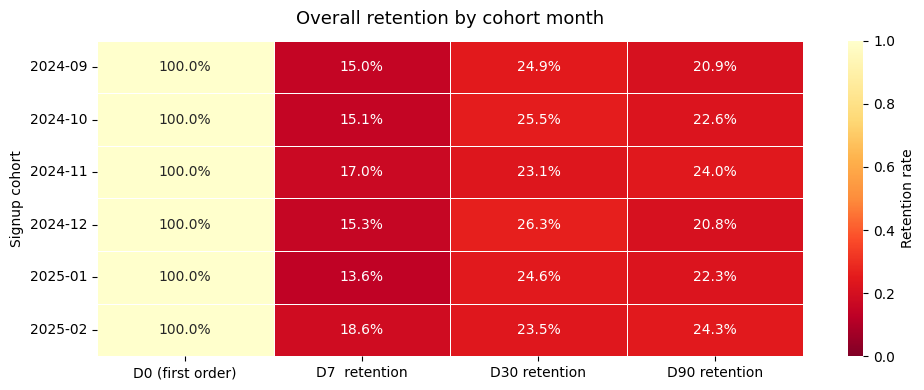

In [17]:
cohort_agg = (
    retention_rates
    .groupby('signup_month')
    .apply(lambda g: pd.Series({
        'D0 (first order)': 1.0,
        'D7  retention':    g['active_d7'].sum()  / g['cohort_size'].sum(),
        'D30 retention':    g['active_d30'].sum() / g['cohort_size'].sum(),
        'D90 retention':    g['active_d90'].sum() / g['cohort_size'].sum(),
    }))
    .reset_index().set_index('signup_month')
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    cohort_agg.astype(float), annot=True, fmt='.1%',
    cmap='YlOrRd_r', linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Retention rate'},
)
ax.set_title('Overall retention by cohort month', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Signup cohort')
plt.tight_layout()
plt.savefig('chart1_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Retention by Acquisition Channel (D7 / D30 / D90)

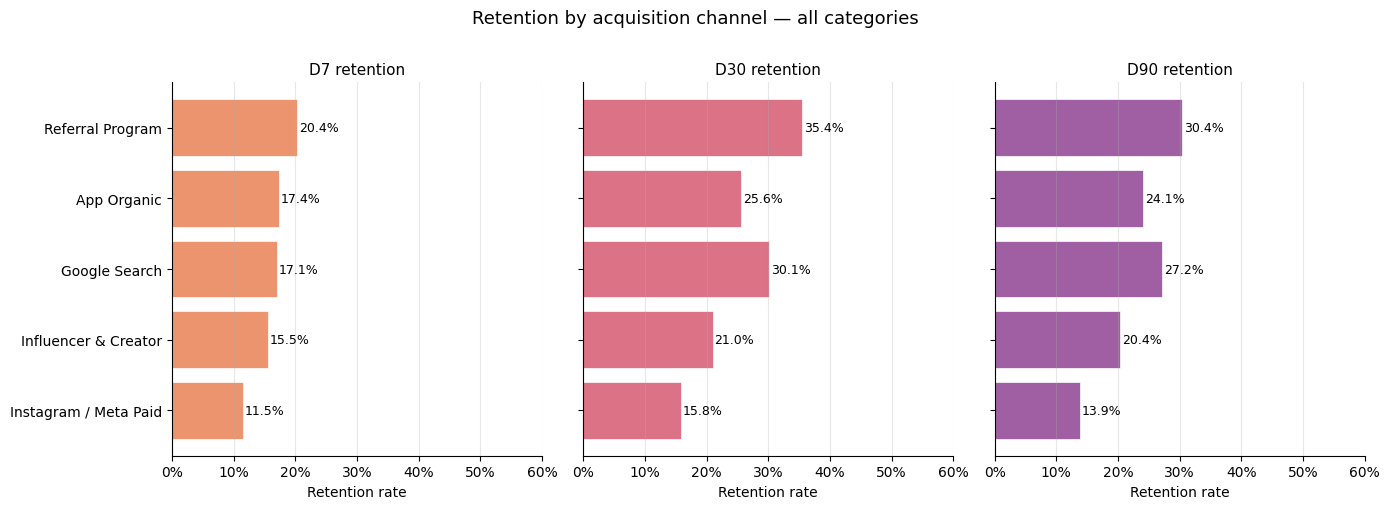

In [18]:
channel_agg = (
    retention_rates
    .groupby('acq_channel')
    .apply(lambda g: pd.Series({
        'D7':  g['active_d7'].sum()  / g['cohort_size'].sum(),
        'D30': g['active_d30'].sum() / g['cohort_size'].sum(),
        'D90': g['active_d90'].sum() / g['cohort_size'].sum(),
    }))
    .reset_index()
    .sort_values('D7', ascending=True)
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
windows = ['D7', 'D30', 'D90']
colors  = ['#e87d4e', '#d4536c', '#8b3a8f']

for ax, window, color in zip(axes, windows, colors):
    bars = ax.barh(channel_agg['acq_channel'], channel_agg[window],
                   color=color, alpha=0.82, edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, channel_agg[window]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    ax.set_title(f'{window} retention', fontsize=11)
    ax.set_xlim(0, 0.60)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel('Retention rate')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Retention by acquisition channel — all categories', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('chart2_channel_retention.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Retention by First Category (D7 / D30 / D90)

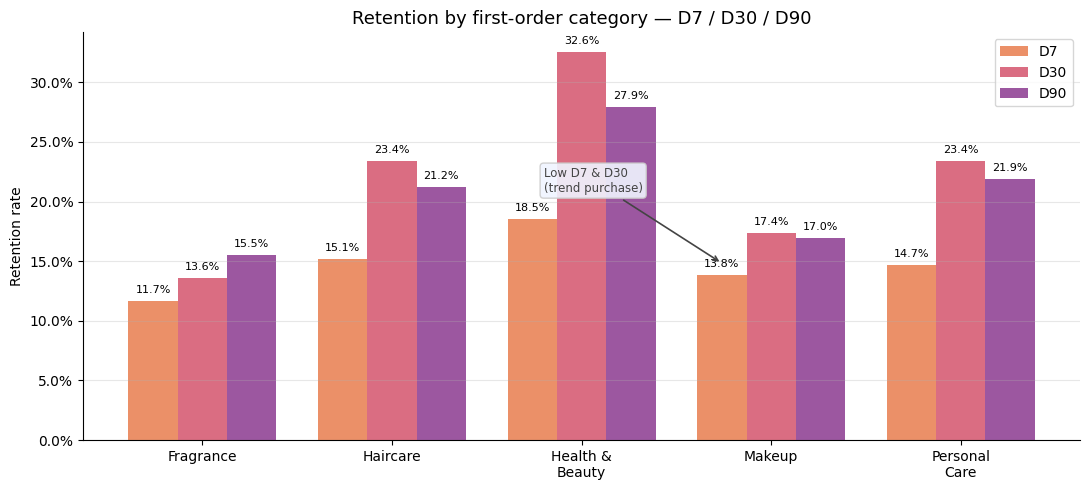

In [19]:
cat_agg = (
    retention_rates
    .groupby('first_category')
    .apply(lambda g: pd.Series({
        'D7':  g['active_d7'].sum()  / g['cohort_size'].sum(),
        'D30': g['active_d30'].sum() / g['cohort_size'].sum(),
        'D90': g['active_d90'].sum() / g['cohort_size'].sum(),
    }))
    .reset_index()
)

cat_labels = {
    'Health & Beauty': 'Health &\nBeauty',
    'Fragrance':        'Fragrance',
    'Personal Care':    'Personal\nCare',
    'Haircare':         'Haircare',
    'Makeup':           'Makeup',
}
cat_agg['label'] = cat_agg['first_category'].map(cat_labels)

x = np.arange(len(cat_agg))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, cat_agg['D7'],  w, label='D7',  color='#e87d4e', alpha=0.85)
b2 = ax.bar(x,     cat_agg['D30'], w, label='D30', color='#d4536c', alpha=0.85)
b3 = ax.bar(x + w, cat_agg['D90'], w, label='D90', color='#8b3a8f', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.1%}', ha='center', va='bottom', fontsize=8)

idx_bs = cat_agg.index[cat_agg['first_category'] == 'Health & Beauty'].tolist()
if idx_bs:
    idx_bs = idx_bs[0]
    ax.annotate(
        'D30 > D7 inversion\n(replenishment cycle)',
        xy=(x[idx_bs], cat_agg.loc[idx_bs, 'D30'] + 0.02),
        xytext=(x[idx_bs] + 0.7, cat_agg.loc[idx_bs, 'D30'] + 0.08),
        arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
        fontsize=8.5, color='#444',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff7e6', edgecolor='#ccc', alpha=0.9)
    )

idx_mk = cat_agg.index[cat_agg['first_category'] == 'Makeup'].tolist()
if idx_mk:
    idx_mk = idx_mk[0]
    ax.annotate(
        'Low D7 & D30\n(trend purchase)',
        xy=(x[idx_mk] - w, cat_agg.loc[idx_mk, 'D7'] + 0.01),
        xytext=(x[idx_mk] - 1.2, cat_agg.loc[idx_mk, 'D7'] + 0.07),
        arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
        fontsize=8.5, color='#444',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f4ff', edgecolor='#ccc', alpha=0.9)
    )

ax.set_xticks(x)
ax.set_xticklabels(cat_agg['label'], fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Retention rate')
ax.set_title('Retention by first-order category — D7 / D30 / D90', fontsize=13)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_category_retention.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Channel x Category Heatmap (D30 retention)

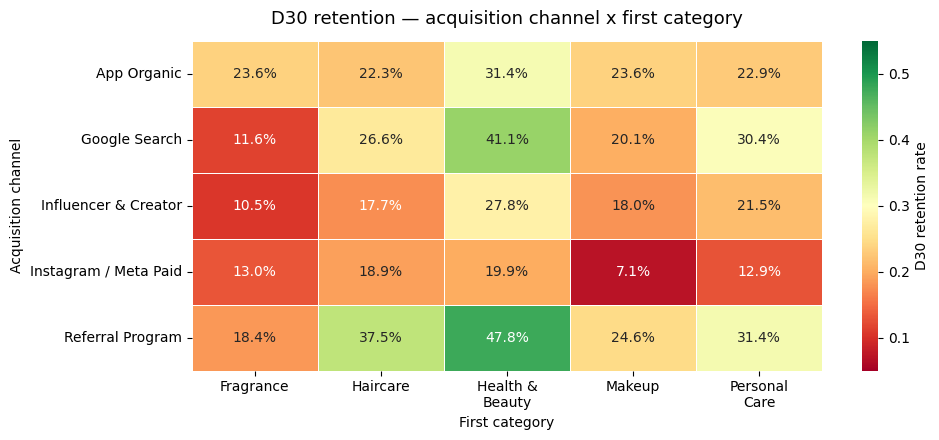

In [13]:
pivot_d30 = (
    retention_rates
    .groupby(['acq_channel', 'first_category'])
    .apply(lambda g: g['active_d30'].sum() / g['cohort_size'].sum())
    .reset_index(name='retention_d30')
    .pivot(index='acq_channel', columns='first_category', values='retention_d30')
)
pivot_d30.columns = [cat_labels.get(c, c) for c in pivot_d30.columns]

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(
    pivot_d30, annot=True, fmt='.1%', cmap='RdYlGn',
    linewidths=0.5, linecolor='white', vmin=0.05, vmax=0.55, ax=ax,
    cbar_kws={'label': 'D30 retention rate'},
)
ax.set_title('D30 retention — acquisition channel x first category', fontsize=13, pad=12)
ax.set_xlabel('First category')
ax.set_ylabel('Acquisition channel')
plt.tight_layout()
plt.savefig('chart4_channel_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Retention Curves by Channel (D7 → D30 → D90)

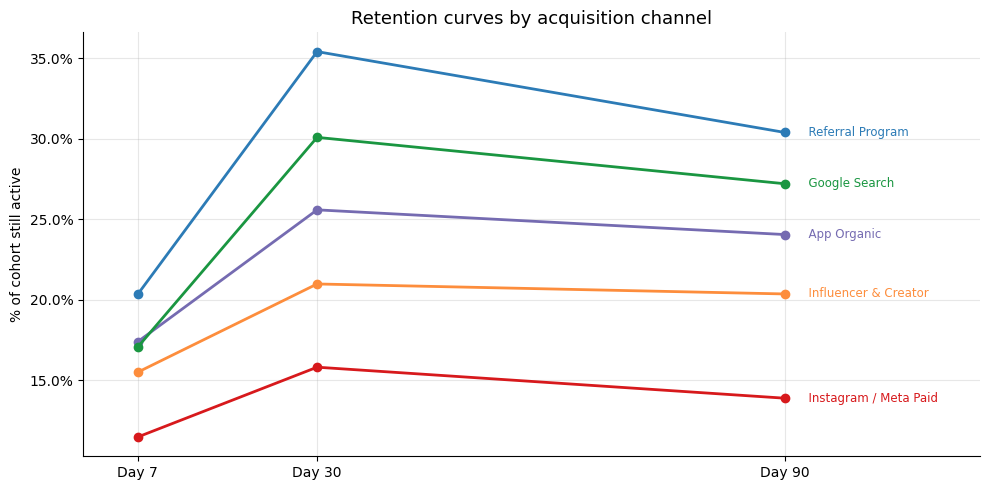

In [14]:
curve_data = (
    retention_rates
    .groupby('acq_channel')
    .apply(lambda g: pd.Series({
        'D7':  g['active_d7'].sum()  / g['cohort_size'].sum(),
        'D30': g['active_d30'].sum() / g['cohort_size'].sum(),
        'D90': g['active_d90'].sum() / g['cohort_size'].sum(),
    }))
    .reset_index()
)

palette = {
    'Referral Program': '#2c7bb6',
    'Google Search':    '#1a9641',
    'App Organic':      '#756bb1',
    'Influencer & Creator': '#fd8d3c',
    'Instagram / Meta Paid': '#d7191c',
}

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in curve_data.iterrows():
    ch     = row['acq_channel']
    values = [row['D7'], row['D30'], row['D90']]
    ax.plot([7, 30, 90], values, marker='o', linewidth=2, markersize=6,
            color=palette.get(ch, 'gray'), label=ch)
    ax.text(92, values[-1], f'  {ch}', va='center',
            fontsize=8.5, color=palette.get(ch, 'gray'))

ax.set_xticks([7, 30, 90])
ax.set_xticklabels(['Day 7', 'Day 30', 'Day 90'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('% of cohort still active')
ax.set_title('Retention curves by acquisition channel', fontsize=13)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('chart5_retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Summary Statistics
Run this last. The printed numbers feed directly into the insight doc.

In [ ]:
print('=' * 60)
print('SUMMARY STATISTICS')
print('=' * 60)

totals = retention_rates.agg(
    {'active_d7': 'sum', 'active_d30': 'sum', 'active_d90': 'sum', 'cohort_size': 'sum'}
)
print(f"\nOverall D7  retention : {totals['active_d7']  / totals['cohort_size']:.1%}")
print(f"Overall D30 retention : {totals['active_d30'] / totals['cohort_size']:.1%}")
print(f"Overall D90 retention : {totals['active_d90'] / totals['cohort_size']:.1%}")

print('\n-- D30 retention by channel --')
ch_d30 = (
    retention_rates.groupby('acq_channel')
    .apply(lambda g: round(g['active_d30'].sum() / g['cohort_size'].sum(), 4))
    .sort_values(ascending=False)
)
print(ch_d30.to_string())

print('\n-- D7 vs D30 by category (positive D30_minus_D7 = replenishment signal) --')
cat_windows = (
    retention_rates.groupby('first_category')
    .apply(lambda g: pd.Series({
        'cohort_n': int(g['cohort_size'].sum()),
        'D7':       round(g['active_d7'].sum()  / g['cohort_size'].sum(), 4),
        'D30':      round(g['active_d30'].sum() / g['cohort_size'].sum(), 4),
        'D90':      round(g['active_d90'].sum() / g['cohort_size'].sum(), 4),
        'D30_minus_D7': round(
            g['active_d30'].sum() / g['cohort_size'].sum() -
            g['active_d7'].sum()  / g['cohort_size'].sum(), 4
        ),
    }))
    .sort_values('D30_minus_D7', ascending=False)
)
display(cat_windows)

print('\n-- Segment spotlight --')
for ch, cat in [
    ('Instagram / Meta Paid', 'Makeup'),
    ('Google Search', 'Health & Beauty'),
    ('Referral Program', 'Health & Beauty'),
]:
    seg = retention_rates[
        (retention_rates['acq_channel'] == ch) &
        (retention_rates['first_category'] == cat)
    ]
    if not seg.empty:
        n   = seg['cohort_size'].sum()
        d7  = seg['active_d7'].sum()  / n
        d30 = seg['active_d30'].sum() / n
        d90 = seg['active_d90'].sum() / n
        print(f"{ch:20s} x {cat:22s} | n={n:4d} | D7={d7:.1%}  D30={d30:.1%}  D90={d90:.1%}")


print('\n-- Cohort sizes by signup month --')
print(retention_rates.groupby('signup_month')['cohort_size'].sum().to_string())

retention_rates
print('\n-- Full retention_rates table --')
display(retention_rates.sort_values(['signup_month', 'acq_channel', 'first_category']))

SUMMARY STATISTICS

Overall D7  retention : 15.7%
Overall D30 retention : 24.7%
Overall D90 retention : 22.5%

-- D30 retention by channel --
acq_channel
Referral Program         0.3543
Google Search            0.3010
App Organic              0.2560
Influencer & Creator     0.2099
Instagram / Meta Paid    0.1582

-- D7 vs D30 by category (positive D30_minus_D7 = replenishment signal) --


,cohort_n,D7,D30,D90,D30_minus_D7
first_category,,,,,
Health & Beauty,1738.0,0.1853,0.3257,0.2791,0.1404
Personal Care,1000.0,0.1470,0.2340,0.2190,0.0870
Haircare,1010.0,0.1515,0.2337,0.2119,0.0822
Makeup,730.0,0.1384,0.1740,0.1699,0.0356
Fragrance,522.0,0.1169,0.1360,0.1552,0.0192



-- Segment spotlight --
Instagram / Meta Paid x Makeup                 | n= 168 | D7=8.9%  D30=7.1%  D90=10.7%
Google Search        x Health & Beauty        | n= 642 | D7=21.7%  D30=41.1%  D90=36.9%
Referral Program     x Health & Beauty        | n= 134 | D7=25.4%  D30=47.8%  D90=35.8%

-- Cohort sizes by signup month --
signup_month
2024-09    802
2024-10    863
2024-11    828
2024-12    862
2025-01    896
2025-02    749

-- Full retention_rates table --


,signup_month,acq_channel,first_category,cohort_size,active_d7,active_d30,active_d90,retention_d7,retention_d30,retention_d90
0,2024-09,App Organic,Fragrance,12,4,7,1,0.3333,0.5833,0.0833
1,2024-09,App Organic,Haircare,31,1,4,6,0.0323,0.1290,0.1935
2,2024-09,App Organic,Health & Beauty,33,5,13,7,0.1515,0.3939,0.2121
3,2024-09,App Organic,Makeup,20,5,3,5,0.2500,0.1500,0.2500
4,2024-09,App Organic,Personal Care,19,3,6,2,0.1579,0.3158,0.1053
...,...,...,...,...,...,...,...,...,...,...
145,2025-02,Referral Program,Fragrance,7,2,0,2,0.2857,0.0000,0.2857
146,2025-02,Referral Program,Haircare,12,3,3,5,0.2500,0.2500,0.4167
147,2025-02,Referral Program,Health & Beauty,19,8,11,8,0.4211,0.5789,0.4211
148,2025-02,Referral Program,Makeup,6,0,4,2,0.0000,0.6667,0.3333
